In [1]:

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score,classification_report, average_precision_score, make_scorer, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define Features and target variable

In [2]:
# Define features and target variable
features = [
    # encoded station/service
    'StationCode_TE',
    'Service:Type_Intercity',
    'Service:Type_Intercity direct',
    'Service:Type_Sprinter',
    # temporal
    'Hour_sin',
    'Hour_cos',
    'DayOfWeek_sin',
    'DayOfWeek_cos',
    'Month_sin',
    'Month_cos',
    'IsWeekend',
    'RushHour',
    # operational context
    'StationTraffic',
    'Stop:Platform change',
    'arrival_scheduled',
    'departure_scheduled',
    # weather
    'Wind Direction',
    'Hourly Mean Wind Speed',
    'Wind Speed last 10 Minutes',
    'Max Wind Speed',
    'Temperature',
    'Dew Point temperature',
    'Sunshine Duration',
    'Global Radiation',
    'Precipitation Duration',
    'Precipitation Amount',
    'Air Pressure',
    'Horizontal Visibility',
    'Cloud Cover',
    'Humidity',
    'Fog',
    'Rainfall',
    'Snowfall',
    'Thunder',
    'Hail',
]

target = "is_cancelled"

# Define chunk reader

In [3]:
# Prepare for chunked reading
cols = features + [target]
chunk_size = 1_000_000
sample_size = 1_000_000
random_state = 42

dtype_map = {col: "float32" for col in features}
dtype_map[target] = "int8"


# Read CSV in chunks
def chunk_reader(file_path):
    for chunk in pd.read_csv(
        file_path,
        usecols=cols,
        dtype=dtype_map,
        chunksize=chunk_size
    ):
        chunk = chunk.reindex(columns=cols, fill_value=0) # Ensure all columns are present

        X_chunk = chunk[features]
        y_chunk = chunk[target]

        yield X_chunk, y_chunk # Yield the chunk for processing
        
# Count classes
not_cancelled_total = 0
cancelled_total = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):
    not_cancelled_total += (y_chunk == 0).sum()
    cancelled_total += (y_chunk == 1).sum()

total_rows = not_cancelled_total + cancelled_total

print(f"Train not cancelled: {not_cancelled_total:,}")
print(f"Train cancelled: {cancelled_total:,}")
print(f"Train total:     {total_rows:,}")

# Decide sample sizes
not_cancelled_sample_size = int(sample_size * not_cancelled_total / total_rows)
cancelled_sample_size = sample_size - not_cancelled_sample_size

print(f"Sampling not cancelled: {not_cancelled_sample_size:,}")
print(f"Sampling cancelled: {cancelled_sample_size:,}")

Train not cancelled: 43,903,090
Train cancelled: 4,479,366
Train total:     48,382,456
Sampling not cancelled: 907,417
Sampling cancelled: 92,583


# Distribution cancelled/not cancelled 

In [4]:
# Generate random numbers for sampling (default_rng is faster)
rng = np.random.default_rng(random_state)

X_not_cancelled_parts = []
y_not_cancelled_parts = []
X_cancelled_parts = []
y_cancelled_parts = []

not_cancelled_seen = 0
cancelled_seen = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):

    # Create masks for cancelled and not cancelled
    not_cancelled_mask = y_chunk == 0
    cancelled_mask = y_chunk == 1
    
    # Split the chunk into cancelled and not cancelled
    X_not_cancelled = X_chunk.loc[not_cancelled_mask]
    y_not_cancelled = y_chunk.loc[not_cancelled_mask]

    X_cancelled = X_chunk.loc[cancelled_mask]
    y_cancelled = y_chunk.loc[cancelled_mask]

    # sample fraction based on remaining needed / remaining available
    neg_remaining_needed = not_cancelled_sample_size - sum(len(p) for p in y_not_cancelled_parts)
    pos_remaining_needed = cancelled_sample_size - sum(len(p) for p in y_cancelled_parts)

    neg_remaining_total = not_cancelled_total - not_cancelled_seen
    pos_remaining_total = cancelled_total - cancelled_seen

    # Sample not cancelled
    if neg_remaining_needed > 0 and len(X_not_cancelled) > 0:
        p_neg = min(1.0, neg_remaining_needed / max(neg_remaining_total, 1))
        keep_neg = rng.random(len(X_not_cancelled)) < p_neg

        X_not_cancelled_parts.append(X_not_cancelled.loc[keep_neg])
        y_not_cancelled_parts.append(y_not_cancelled.loc[keep_neg])
        
    # Sample cancelled
    if pos_remaining_needed > 0 and len(X_cancelled) > 0:
        p_pos = min(1.0, pos_remaining_needed / max(pos_remaining_total, 1))
        keep_pos = rng.random(len(X_cancelled)) < p_pos

        X_cancelled_parts.append(X_cancelled.loc[keep_pos])
        y_cancelled_parts.append(y_cancelled.loc[keep_pos])

    not_cancelled_seen += len(X_not_cancelled)
    cancelled_seen += len(X_cancelled)

# Combine sampled parts
X_train_sample = pd.concat(X_not_cancelled_parts + X_cancelled_parts, axis=0)
y_train_sample = pd.concat(y_not_cancelled_parts + y_cancelled_parts, axis=0)

# Shuffle final sample
shuffle_idx = rng.permutation(len(X_train_sample))
X_train_sample = X_train_sample.iloc[shuffle_idx].to_numpy(dtype=np.float32, copy=False)
y_train_sample = y_train_sample.iloc[shuffle_idx].to_numpy(copy=False)

# Finding the best Parameters

In [5]:
# Custom F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

# Calculate imbalance ratio for XGBoost
neg_count = np.sum(y_train_sample == 0)
pos_count = np.sum(y_train_sample == 1)

scale_pos_weight_base = neg_count / pos_count

print("Negative count:", neg_count)
print("Positive count:", pos_count)
print("Base scale_pos_weight:", round(scale_pos_weight_base, 2))


# XGBoost parameter grid for imbalanced classification
param_dist = {
    "n_estimators": [100, 200, 300, 500, 800],
    "max_depth": [4, 5, 6, 8, 10],
    "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [10, 20, 50, 75, 100],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1, 2],
    "reg_lambda": [1, 2, 5, 10, 20],

    # XGBoost's class imbalance parameter
    "scale_pos_weight": [
        scale_pos_weight_base * 1,
        scale_pos_weight_base * 3,
        scale_pos_weight_base * 5,
        scale_pos_weight_base * 7,
    ],
}

# Use smaller subset for tuning
X_tune, X_val_tune, y_tune, y_val_tune = train_test_split(
    X_train_sample,
    y_train_sample,
    train_size=0.3,
    stratify=y_train_sample,
    random_state=42
)

# Base XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random search
xgb_tuned = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_tune, y_tune)

print("Best CV F2 score:", round(xgb_tuned.best_score_, 4))
print("Best parameters:")
print(xgb_tuned.best_params_)

Negative count: 907281
Positive count: 92516
Base scale_pos_weight: 9.81
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV F2 score: 0.4278
Best parameters:
{'subsample': 0.6, 'scale_pos_weight': np.float64(9.806746941069653), 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 50, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 1.0}


# Define Evaluation Method

In [6]:
# Evaluate CSV split in chunks with custom threshold
def evaluate_split_xgb(name, file_path, model, threshold):
    y_true_parts = []
    y_pred_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_pred_parts.append(y_pred)
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_pred_all = np.concatenate(y_pred_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    f2 = fbeta_score(y_true_all, y_pred_all, beta=2)
    pr_auc = average_precision_score(y_true_all, y_prob_all)

    print(f"\n{name}")
    print("Threshold:", round(threshold, 2))
    print("F2 Score:", round(f2, 4))
    print(classification_report(y_true_all, y_pred_all, digits=3, zero_division=0))
    print("PR-AUC:", round(pr_auc, 4))

    return {
        "threshold": threshold,
        "f2": f2,
        "pr_auc": pr_auc
    }


# Find best threshold using validation data
def find_best_threshold_xgb(file_path, model):
    y_true_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    best_threshold = 0.5
    best_f2 = -1

    for threshold in np.arange(0.01, 0.99, 0.01):
        y_pred_all = (y_prob_all >= threshold).astype(int)
        f2 = fbeta_score(y_true_all, y_pred_all, beta=2)

        if f2 > best_f2:
            best_f2 = f2
            best_threshold = threshold

    print("Best validation threshold:", round(best_threshold, 2))
    print("Best validation F2:", round(best_f2, 4))

    return best_threshold

# XGBoost: Class weighting (BEST MODEL)

In [7]:
# Train final model with best parameters on full sample
best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 5.0,
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_class = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_class.fit(X_train_sample, y_train_sample)

print(f"XGBoost trained on {len(y_train_sample):,} samples")

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_class)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_class,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_class,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_class,
    threshold=best_threshold
)

XGBoost trained on 999,797 samples
Best validation threshold: 0.21
Best validation F2: 0.3787

Train
Threshold: 0.21
F2 Score: 0.4092
              precision    recall  f1-score   support

           0      0.974     0.374     0.541  43903090
           1      0.128     0.903     0.225   4479366

    accuracy                          0.423  48382456
   macro avg      0.551     0.639     0.383  48382456
weighted avg      0.896     0.423     0.512  48382456

PR-AUC: 0.3529

Validation
Threshold: 0.21
F2 Score: 0.3787
              precision    recall  f1-score   support

           0      0.942     0.371     0.532   9333880
           1      0.123     0.794     0.212   1033789

    accuracy                          0.413  10367669
   macro avg      0.532     0.582     0.372  10367669
weighted avg      0.860     0.413     0.500  10367669

PR-AUC: 0.1644

Test
Threshold: 0.21
F2 Score: 0.4307
              precision    recall  f1-score   support

           0      0.935     0.323     0.480

# XGBoost: RandomUnderSampler

In [8]:

# Train model with best parameters on full sample with undersampling
rus = RandomUnderSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_under, y_train_under = rus.fit_resample(
    X_train_sample,
    y_train_sample
)

print("Before:", Counter(y_train_sample))
print("After:", Counter(y_train_under))

best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 1.0, 
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_rus = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_rus.fit(X_train_under, y_train_under)

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_rus)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_rus,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_rus,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_rus,
    threshold=best_threshold
)

Before: Counter({np.int8(0): 907281, np.int8(1): 92516})
After: Counter({np.int8(0): 370064, np.int8(1): 92516})
Best validation threshold: 0.12
Best validation F2: 0.3778

Train
Threshold: 0.12
F2 Score: 0.399
              precision    recall  f1-score   support

           0      0.972     0.345     0.509  43903090
           1      0.123     0.904     0.217   4479366

    accuracy                          0.397  48382456
   macro avg      0.548     0.624     0.363  48382456
weighted avg      0.894     0.397     0.482  48382456

PR-AUC: 0.3327

Validation
Threshold: 0.12
F2 Score: 0.3778
              precision    recall  f1-score   support

           0      0.943     0.331     0.490   9333880
           1      0.120     0.821     0.209   1033789

    accuracy                          0.380  10367669
   macro avg      0.531     0.576     0.349  10367669
weighted avg      0.861     0.380     0.462  10367669

PR-AUC: 0.1618

Test
Threshold: 0.12
F2 Score: 0.4288
              precisi

# XGBoost: RandomOverSampler

In [9]:
# Train model with best parameters on full sample with oversampling
ros = RandomOverSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_over, y_train_over = ros.fit_resample(
    X_train_sample,
    y_train_sample
)

print("Before:", Counter(y_train_sample))
print("After:", Counter(y_train_over))

best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 1.0, 
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_ros = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_ros.fit(X_train_over, y_train_over)

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_ros)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_ros,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_ros,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_ros,
    threshold=best_threshold
)

Before: Counter({np.int8(0): 907281, np.int8(1): 92516})
After: Counter({np.int8(0): 907281, np.int8(1): 226820})
Best validation threshold: 0.12
Best validation F2: 0.3784

Train
Threshold: 0.12
F2 Score: 0.4054
              precision    recall  f1-score   support

           0      0.973     0.369     0.535  43903090
           1      0.127     0.899     0.222   4479366

    accuracy                          0.418  48382456
   macro avg      0.550     0.634     0.379  48382456
weighted avg      0.894     0.418     0.506  48382456

PR-AUC: 0.3481

Validation
Threshold: 0.12
F2 Score: 0.3784
              precision    recall  f1-score   support

           0      0.942     0.358     0.519   9333880
           1      0.122     0.802     0.211   1033789

    accuracy                          0.403  10367669
   macro avg      0.532     0.580     0.365  10367669
weighted avg      0.860     0.403     0.489  10367669

PR-AUC: 0.162

Test
Threshold: 0.12
F2 Score: 0.4306
              precis

# XGBoost: Sample weighting

In [10]:
# Sample weighting
sample_weight = np.where(y_train_sample == 1, 5.0, 1.0)

best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 1.0, 
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_weighted = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_weighted.fit(
    X_train_sample,
    y_train_sample,
    sample_weight=sample_weight
)

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_weighted)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_weighted,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_weighted,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_weighted,
    threshold=best_threshold
)

Best validation threshold: 0.2
Best validation F2: 0.3775

Train
Threshold: 0.2
F2 Score: 0.4012
              precision    recall  f1-score   support

           0      0.976     0.335     0.499  43903090
           1      0.123     0.918     0.218   4479366

    accuracy                          0.389  48382456
   macro avg      0.549     0.626     0.358  48382456
weighted avg      0.897     0.389     0.473  48382456

PR-AUC: 0.3506

Validation
Threshold: 0.2
F2 Score: 0.3775
              precision    recall  f1-score   support

           0      0.943     0.327     0.486   9333880
           1      0.119     0.823     0.208   1033789

    accuracy                          0.377  10367669
   macro avg      0.531     0.575     0.347  10367669
weighted avg      0.861     0.377     0.458  10367669

PR-AUC: 0.1635

Test
Threshold: 0.2
F2 Score: 0.4304
              precision    recall  f1-score   support

           0      0.936     0.298     0.452   9105889
           1      0.144     

# Feature Importance

In [11]:
# Feature importance analysis with best model - XGBoost: Class weighting (xgb_class)
importance_gain = xgb_class.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature_index": importance_gain.keys(),
    "gain": importance_gain.values()
})

importance_df["feature"] = importance_df["feature_index"].apply(
    lambda x: features[int(x[1:])]
)

importance_df = importance_df[["feature", "gain"]].sort_values(
    "gain",
    ascending=False
)

print(importance_df.head(20))

                          feature         gain
3           Service:Type_Sprinter  1031.114014
12           Stop:Platform change   163.738434
13              arrival_scheduled   101.666039
14            departure_scheduled   101.102448
2   Service:Type_Intercity direct    85.331711
8                       Month_sin    61.216278
31                       Snowfall    56.051830
9                       Month_cos    55.688694
0                  StationCode_TE    54.249184
6                   DayOfWeek_sin    51.313519
5                        Hour_cos    48.992218
25                   Air Pressure    48.074867
7                   DayOfWeek_cos    47.715965
18                 Max Wind Speed    47.680435
16         Hourly Mean Wind Speed    46.781990
20          Dew Point temperature    45.216602
23         Precipitation Duration    43.680046
19                    Temperature    43.041965
24           Precipitation Amount    42.784172
15                 Wind Direction    42.468662


In [12]:
# Create validation set for permutation importance

X_val_perm, y_val_perm = next(chunk_reader("val_data.csv"))

X_val_perm = X_val_perm.to_numpy(dtype=np.float32, copy=False)
y_val_perm = y_val_perm.to_numpy(copy=False)

print("Permutation validation sample shape:", X_val_perm.shape)
print("Permutation validation target shape:", y_val_perm.shape)

best_threshold = 0.25

def f2_threshold_scorer(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    return fbeta_score(y, y_pred, beta=2)

perm = permutation_importance(
    xgb_class,
    X_val_perm,
    y_val_perm,
    scoring=f2_threshold_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 permutation importances:")
print(perm_df.head(20))

print("\nLowest 10 permutation importances:")
print(perm_df.tail(10))

Permutation validation sample shape: (1000000, 35)
Permutation validation target shape: (1000000,)

Top 20 permutation importances:
                          feature  importance_mean  importance_std
0                  StationCode_TE         0.071025        0.000770
3           Service:Type_Sprinter         0.052039        0.000617
13           Stop:Platform change         0.007815        0.000145
15            departure_scheduled         0.006381        0.000224
12                 StationTraffic         0.005558        0.000280
14              arrival_scheduled         0.005548        0.000179
27          Horizontal Visibility         0.005275        0.000172
5                        Hour_cos         0.004902        0.000341
1          Service:Type_Intercity         0.004258        0.000117
7                   DayOfWeek_cos         0.003246        0.000132
28                    Cloud Cover         0.002320        0.000141
16                 Wind Direction         0.002217        0.0002

# Error Analysis

In [13]:
# Get predictions for test set in a DataFrame
def get_predictions_dataframe(file_path, model, threshold):
    parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        chunk_results = X_chunk.copy()
        chunk_results["y_true"] = y_chunk.to_numpy(copy=False)
        chunk_results["y_prob"] = y_prob
        chunk_results["y_pred"] = y_pred

        parts.append(chunk_results)

    return pd.concat(parts, axis=0, ignore_index=True)


test_pred_df = get_predictions_dataframe(
    file_path="test_data.csv",
    model=xgb_class,
    threshold=0.25
)

test_pred_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10367670 entries, 0 to 10367669
Data columns (total 38 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   StationCode_TE                 float32
 1   Service:Type_Intercity         float32
 2   Service:Type_Intercity direct  float32
 3   Service:Type_Sprinter          float32
 4   Hour_sin                       float32
 5   Hour_cos                       float32
 6   DayOfWeek_sin                  float32
 7   DayOfWeek_cos                  float32
 8   Month_sin                      float32
 9   Month_cos                      float32
 10  IsWeekend                      float32
 11  RushHour                       float32
 12  StationTraffic                 float32
 13  Stop:Platform change           float32
 14  arrival_scheduled              float32
 15  departure_scheduled            float32
 16  Wind Direction                 float32
 17  Hourly Mean Wind Speed         float32
 18  Wind Speed 

# Confusion Matrix

[[4244661 4861228]
 [ 339716  922065]]


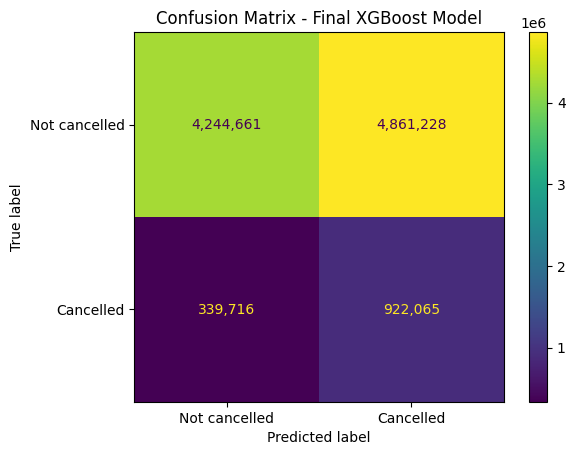

In [14]:
# Confusion matrix for test set
cm = confusion_matrix(
    test_pred_df["y_true"],
    test_pred_df["y_pred"]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not cancelled", "Cancelled"]
)

disp.plot(values_format=",d")
plt.title("Confusion Matrix - Final XGBoost Model")
plt.show()

In [15]:
test_pred_df["error_type"] = np.select(
    [
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 1),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 1),
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
    ],
    default="Unknown"
)

print(test_pred_df["error_type"].value_counts())

error_type
False Positive    4861228
True Negative     4244661
True Positive      922065
False Negative     339716
Name: count, dtype: int64


# Subgroup bias analysis

In [16]:
# Subgroups are:
# StationCode_TE
# Service type
# Hour / RushHour
# IsWeekend
# StationTraffic

def subgroup_metrics(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(group_col):
        if len(group_df) < 1000:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        rows.append({
            "group": group_value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("f2", ascending=True)


print(subgroup_metrics(test_pred_df, "Service:Type_Intercity"))
print(subgroup_metrics(test_pred_df, "Service:Type_Sprinter"))
print(subgroup_metrics(test_pred_df, "IsWeekend"))
print(subgroup_metrics(test_pred_df, "RushHour"))

# For one-hot service type, create one readable service column first:
def get_service_type(row):
    if row["Service:Type_Intercity"] == 1:
        return "Intercity"
    elif row["Service:Type_Intercity direct"] == 1:
        return "Intercity direct"
    elif row["Service:Type_Sprinter"] == 1:
        return "Sprinter"
    else:
        return "Other"

test_pred_df["service_type"] = test_pred_df.apply(get_service_type, axis=1)

service_bias = subgroup_metrics(test_pred_df, "service_type")
print(service_bias)

   group        n  actual_cancel_rate  predicted_cancel_rate  \
0    0.0  7038088            0.094014               0.397249   
1    1.0  3329582            0.180233               0.897235   

   precision_cancelled  recall_cancelled        f2  
0             0.126978          0.536537  0.326145  
1             0.189813          0.944923  0.526233  
   group        n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  6846386            0.089536               0.386627   
0    0.0  3521284            0.184247               0.890667   

   precision_cancelled  recall_cancelled        f2  
1             0.118636          0.512286  0.307933  
0             0.193871          0.937192  0.530440  
   group        n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  2476407            0.088803               0.435104   
0    0.0  7891263            0.132028               0.596330   

   precision_cancelled  recall_cancelled        f2  
1             0.134461          0.658811  0.370133

# Rare Weather Conditions analysis

In [17]:
weather_flags = ["Fog", "Rainfall", "Snowfall", "Thunder", "Hail"]

weather_results = []

for weather_col in weather_flags:
    for value, group_df in test_pred_df.groupby(weather_col):
        if len(group_df) < 1000:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        weather_results.append({
            "weather_feature": weather_col,
            "condition_present": value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

weather_results_df = pd.DataFrame(weather_results).sort_values(
    ["weather_feature", "condition_present"]
)

print(weather_results_df)

  weather_feature  condition_present         n  actual_cancel_rate  \
0             Fog                0.0  10121445            0.122847   
1             Fog                1.0    246225            0.074680   
8            Hail                0.0  10352688            0.121804   
9            Hail                1.0     14982            0.052196   
2        Rainfall                0.0   8570441            0.120835   
3        Rainfall                1.0   1797229            0.125847   
4        Snowfall                0.0  10360674            0.121727   
5        Snowfall                1.0      6996            0.087193   
6         Thunder                0.0  10309093            0.121899   
7         Thunder                1.0     58577            0.087304   

   predicted_cancel_rate  precision_cancelled  recall_cancelled        f2  
0               0.561130             0.160216          0.731818  0.427080  
1               0.421765             0.116785          0.659561  0.341824  
8